# Fase 1 — Contrato temporal y objetivo

**Pregunta:** ¿qué información existía al emitir un pronóstico distrital con un mínimo de dos semanas y cuatro como objetivo principal y qué definición de desenlace conviene evaluar?

**Hipótesis de trabajo:** el panel integrado permite auditar los orígenes `t−2` y `t−4`, pero las definiciones de brote y el uso de 2025 requieren decisiones explícitas. Este notebook compara candidatos sin adoptar ninguno como objetivo definitivo. Los parámetros D1–D4 proceden del EDA y son ilustrativos.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import matplotlib.pyplot as plt
import pandas as pd
from src.eda.carga import cargar_integrado
from src.eda.objetivo import (brote_umbral_tasa, brote_percentil_distrito,
    brote_canal_endemico, brote_aumento_sostenido, resumen_definicion,
    umbral_canal_endemico)
from src.eda.temporal import asignar_temporada
from src.utils.paths import DOCS, SILVER, SILVER_INTEGRADO
from src.validation.contrato_pronostico import auditar_origen, observaciones_disponibles
from src.validation.expectations_integrado import (coverage_path, load_case_coverage,
    validate_complete)

SALIDA = DOCS / "feature_engineering"
METRICAS = SALIDA / "metricas"
FIGURAS = SALIDA / "figuras" / "fase1_contrato_objetivo"
METRICAS.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

## 1. Panel y origen de pronóstico

**Pregunta:** ¿la llave, la cobertura y la continuidad semanal permiten asociar cada objetivo a sus orígenes `t−2` y `t−4`? Para un objetivo en `t`, una observación de `t−1` sería posterior a ambos orígenes. La fecha de publicación también debe ser anterior al cierre del origen.

In [2]:
df = cargar_integrado()
cobertura = load_case_coverage(coverage_path(SILVER_INTEGRADO))
validate_complete(df, cobertura)
auditorias = {h: auditar_origen(df, horizonte=h) for h in (2, 4)}
resumen_horizontes = {}
for h, audit_h in auditorias.items():
    assert df[["ubigeo", "anio", "semana"]].equals(audit_h[["ubigeo", "anio", "semana"]])
    objetivo_h = audit_h["semana_inicio"]
    origen_h = audit_h["origen_inicio"]
    permitido_h = observaciones_disponibles(
        audit_h, origen_h, origen_h + pd.Timedelta(days=6))
    filtrado_h = observaciones_disponibles(
        audit_h, objetivo_h - pd.Timedelta(weeks=1),
        objetivo_h - pd.Timedelta(weeks=1) + pd.Timedelta(days=6))
    assert permitido_h.equals(origen_h.notna()) and not filtrado_h.any()
    resumen_horizontes[str(h)] = {
        "objetivos_con_origen": int(permitido_h.sum()),
        "objetivos_sin_historia": int(origen_h.isna().sum()),
        "observaciones_t_menos_1_admisibles": int(filtrado_h.sum()),
    }

integridad = {
    "filas": len(df), "columnas": df.shape[1], "distritos": df.ubigeo.nunique(),
    "semanas_por_distrito": int(df.groupby("ubigeo").size().iloc[0]),
    "inicio": str(df.semana_inicio.min().date()), "fin": str(df.semana_inicio.max().date()),
    "nulos": int(df.isna().sum().sum()),
    "llaves_duplicadas": int(df.duplicated(["ubigeo", "anio", "semana"]).sum()),
    "cobertura_verificada": len(cobertura),
    "horizontes": resumen_horizontes,
}
print(json.dumps(integridad, ensure_ascii=False, indent=2))
auditorias[4].loc[(auditorias[4].anio == 2021) & (auditorias[4].semana == 1),
    ["ubigeo", "semana_inicio", "origen_inicio", "origen_cierre"]].head(3)

{
  "filas": 30485,
  "columnas": 35,
  "distritos": 65,
  "semanas_por_distrito": 469,
  "inicio": "2017-01-01",
  "fin": "2025-12-21",
  "nulos": 0,
  "llaves_duplicadas": 0,
  "cobertura_verificada": 30485,
  "horizontes": {
    "2": {
      "objetivos_con_origen": 30355,
      "objetivos_sin_historia": 130,
      "observaciones_t_menos_1_admisibles": 0
    },
    "4": {
      "objetivos_con_origen": 30225,
      "objetivos_sin_historia": 260,
      "observaciones_t_menos_1_admisibles": 0
    }
  }
}


,ubigeo,semana_inicio,origen_inicio,origen_cierre
209,200101,2021-01-03,2020-12-06,2020-12-12
678,200104,2021-01-03,2020-12-06,2020-12-12
1147,200105,2021-01-03,2020-12-06,2020-12-12


## 2. Procedencia y cobertura de los casos

**Pregunta:** ¿qué significa un cero y qué observaciones de la Sala quedan fuera del panel? La cobertura técnica del archivo lateral indica que un valor fue aceptado por el actualizador; no demuestra que la fuente histórica haya notificado explícitamente cero.

In [3]:
sala = pd.read_csv(SILVER / "epi_sala_semanal.csv", dtype={"ubigeo": "string"})
excel = pd.read_csv(SILVER / "epi_piura_semanal.csv", dtype={"ubigeo": "string"})
piura_excel = excel[excel.ubigeo.isin(df.ubigeo.unique()) & excel.anio.between(2017, 2024)]
no_reportan = sorted(set(df.ubigeo) - set(piura_excel.ubigeo))
procedencia = {
    "casos_panel_2025": int(df.loc[df.anio == 2025, "casos_Dengue"].sum()),
    "casos_sala_2025_total": int(sala.casos_Dengue.sum()),
    "casos_sala_semana_53": int(sala.loc[sala.semana == 53, "casos_Dengue"].sum()),
    "filas_sala_semana_53": int((sala.semana == 53).sum()),
    "ceros_panel": int((df.casos_Dengue == 0).sum()),
    "filas_excel_con_cero": int((piura_excel.casos_Dengue == 0).sum()),
    "ubigeos_sin_registro_excel_2017_2024": no_reportan,
}
print(json.dumps(procedencia, ensure_ascii=False, indent=2))

{
  "casos_panel_2025": 1114,
  "casos_sala_2025_total": 1117,
  "casos_sala_semana_53": 3,
  "filas_sala_semana_53": 65,
  "ceros_panel": 23756,
  "filas_excel_con_cero": 0,
  "ubigeos_sin_registro_excel_2017_2024": [
    "200204",
    "200205",
    "200209"
  ]
}


## 3. Calendario epidemiológico

**Pregunta:** ¿el calendario del panel coincide hoy con MMWR y dónde diverge la regla de construcción para semanas futuras? La Sala conserva 2025-S53, ausente del modelo por falta de la fila climática correspondiente.

In [4]:
from src.eda.calidad import semana_epi_mmwr

actual = df[["semana_inicio", "anio", "semana"]].drop_duplicates().reset_index(drop=True)
mmwr_actual = semana_epi_mmwr(actual["semana_inicio"])
diferencias_actuales = ((actual.anio != mmwr_actual.anio_epi) |
    (actual.semana != mmwr_actual.semana_epi)).sum()
futuras = pd.Series(pd.to_datetime(["2025-12-28", "2026-01-04"]))
mmwr_futuro = semana_epi_mmwr(futuras)
iso_futuro = (futuras + pd.Timedelta(days=3)).dt.isocalendar()
calendario = {
    "semanas_actuales_distintas_mmwr": int(diferencias_actuales),
    "filas_semana_53_de_2020": int(((df.anio == 2020) & (df.semana == 53)).sum()),
    "frontera_2025_2026": [
        {"domingo": str(fecha.date()), "mmwr": f"{int(a)}-S{int(s):02d}",
         "regla_pipeline": f"{int(ia)}-S{int(isem):02d}"}
        for fecha, a, s, ia, isem in zip(futuras, mmwr_futuro.anio_epi,
            mmwr_futuro.semana_epi, iso_futuro.year, iso_futuro.week)
    ],
}
assert calendario["semanas_actuales_distintas_mmwr"] == 0
print(json.dumps(calendario, ensure_ascii=False, indent=2))

{
  "semanas_actuales_distintas_mmwr": 0,
  "filas_semana_53_de_2020": 65,
  "frontera_2025_2026": [
    {
      "domingo": "2025-12-28",
      "mmwr": "2025-S53",
      "regla_pipeline": "2026-S01"
    },
    {
      "domingo": "2026-01-04",
      "mmwr": "2026-S01",
      "regla_pipeline": "2026-S02"
    }
  ]
}


## 4. Objetivos candidatos

**Pregunta:** ¿cómo cambian el desbalance y la concentración anual con cada definición del EDA? D1 usa población; D2 calcula un percentil con todo el periodo y debe rehacerse dentro de cada entrenamiento; D3 tiene canal cero con frecuencia; D4 exige tres semanas consecutivas y su etiqueta retrospectiva se confirma más tarde. Ninguna se adopta aquí.

In [5]:
hist = excel[excel.ubigeo.isin(df.ubigeo.unique()) & (excel.anio < 2017)]
marcas = {
    "D1 tasa ≥ 10/100k": brote_umbral_tasa(df, 10),
    "D2 > p90 del distrito": brote_percentil_distrito(df, 0.9),
    "D3 canal endémico": brote_canal_endemico(df, hist, anios_previos=5),
    "D4 aumento sostenido": brote_aumento_sostenido(df, factor=2, ventana=8, k=3, minimo=5),
}
objetivos = {nombre: resumen_definicion(df, marca) for nombre, marca in marcas.items()}
canal_cero_pct = round(float((umbral_canal_endemico(df, hist, anios_previos=5) == 0).mean() * 100), 1)
comparacion = pd.DataFrame(objetivos).T[["filas_positivas", "pct_filas_positivas",
    "razon_negativos_por_positivo", "episodios", "distritos_con_algun_positivo"]]
comparacion["positivos_sin_2025"] = [int(marca[df.anio < 2025].sum()) for marca in marcas.values()]
comparacion

,filas_positivas,pct_filas_positivas,razon_negativos_por_positivo,episodios,distritos_con_algun_positivo,positivos_sin_2025
D1 tasa ≥ 10/100k,4076,13.37,6.5,805,59,4032
D2 > p90 del distrito,2122,6.96,13.4,516,62,2118
D3 canal endémico,5218,17.12,4.8,1176,62,5164
D4 aumento sostenido,755,2.48,39.4,153,45,755


**Lectura del gráfico:** el número de positivos cambia con la definición; la elección exige fijar primero qué debe anticipar la alerta. Esta comparación no mide capacidad predictiva.

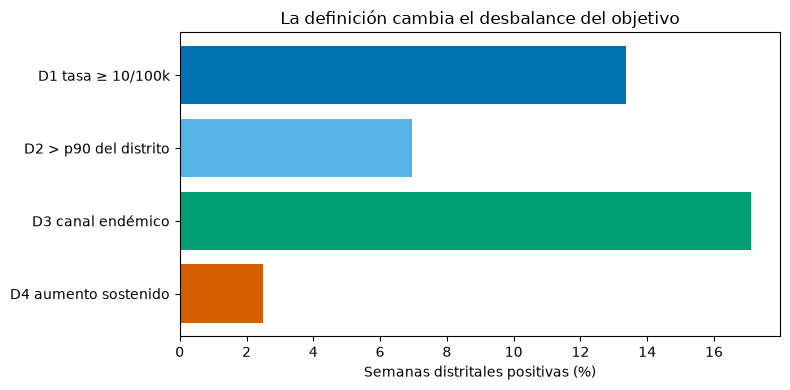

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#0072B2", "#56B4E9", "#009E73", "#D55E00"]
ax.barh(list(objetivos), [x["pct_filas_positivas"] for x in objetivos.values()], color=colores)
ax.invert_yaxis()
ax.set(xlabel="Semanas distritales positivas (%)", title="La definición cambia el desbalance del objetivo")
fig.tight_layout()
fig.savefig(FIGURAS / "01_positivos_por_definicion.png", dpi=160)
plt.show()

## 5. Cortes temporales propuestos

**Pregunta:** ¿qué temporadas permiten evaluar el objetivo sin mezclar semanas futuras de otros distritos? Se usa el valle ilustrativo de la semana 35 del EDA. Para el primer pronóstico de cada temporada de prueba se muestra el último objetivo que podría estar etiquetado al cierre de su origen `t−2` o `t−4`; la disponibilidad real de notificaciones puede exigir un corte anterior. Los casos de 2025 de la Sala son válidos según la decisión actual del proyecto; su inclusión como prueba depende del corte temporal elegido. Los hiperparámetros y transformaciones aprendidas se ajustarán dentro de cada entrenamiento.

In [7]:
temporada = asignar_temporada(df.anio, df.semana, semana_inicio=35)
tabla_folds = []
for anio in [2022, 2023, 2024, 2025]:
    m = temporada.eq(anio)
    inicio = df.loc[m, "semana_inicio"].min()
    fin = df.loc[m, "semana_inicio"].max()
    ultimo_train_2 = inicio - pd.Timedelta(weeks=2)
    ultimo_train_4 = inicio - pd.Timedelta(weeks=4)
    tabla_folds.append({
        "temporada_prueba": anio,
        "inicio_prueba": str(inicio.date()), "fin_prueba": str(fin.date()),
        "ultimo_objetivo_train_h2_sin_demora": str(ultimo_train_2.date()),
        "ultimo_objetivo_train_h4_sin_demora": str(ultimo_train_4.date()),
        "semanas_prueba": int(df.loc[m, "semana_inicio"].nunique()),
        "positivos_D1": int(marcas["D1 tasa ≥ 10/100k"][m].sum()),
        "positivos_D4": int(marcas["D4 aumento sostenido"][m].sum()),
    })
folds = pd.DataFrame(tabla_folds)
folds

,temporada_prueba,inicio_prueba,fin_prueba,ultimo_objetivo_train_h2_sin_demora,ultimo_objetivo_train_h4_sin_demora,semanas_prueba,positivos_D1,positivos_D4
0,2022,2021-08-29,2022-08-21,2021-08-15,2021-08-01,52,628,123
1,2023,2022-08-28,2023-08-20,2022-08-14,2022-07-31,52,1148,300
2,2024,2023-08-27,2024-08-18,2023-08-13,2023-07-30,52,1269,149
3,2025,2024-08-25,2025-08-17,2024-08-11,2024-07-28,52,98,3


## 6. Registro reproducible

Las métricas se guardan fuera de `data/`. Las decisiones pendientes se documentan en `docs/feature_engineering/fase1_contrato_objetivo.md`. Este notebook no genera variables de entrenamiento ni escribe en gold.

In [8]:
resultado = {
    "integridad": integridad,
    "procedencia": procedencia,
    "calendario": calendario,
    "objetivos": objetivos,
    "d3_pct_canal_en_cero": canal_cero_pct,
    "folds_propuestos": tabla_folds,
    "parametros_ilustrativos": {
        "horizontes_semanas": [2, 4], "horizonte_principal": 4,
        "semana_inicio_temporada": 35,
        "D1_umbral_tasa_100k": 10, "D2_percentil": 0.9,
        "D3_anios_previos": 5,
        "D4_factor": 2, "D4_ventana": 8, "D4_k": 3, "D4_minimo": 5,
    },
}
with (METRICAS / "fase1_contrato_objetivo.json").open("w", encoding="utf-8") as f:
    json.dump(resultado, f, ensure_ascii=False, indent=2)
print("Métricas guardadas:", METRICAS / "fase1_contrato_objetivo.json")

Métricas guardadas: C:\Users\Rosa\RufoEsEternoElRegreso\Denguekay\docs\feature_engineering\metricas\fase1_contrato_objetivo.json
